In [ ]:
import kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("darren2020/ct-to-mri-cgan")

print("Path to dataset files:", path)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("phantomxdata/abdomen-pelvis-ct-collection-phantomx")

print("Path to dataset files:", path)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("vbookshelf/spine-fracture-comp-data")

print("Path to dataset files:", path)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")

print("Path to dataset files:", path)

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ct-to-mri-cgan' dataset.
Path to dataset files: /kaggle/input/ct-to-mri-cgan
Using Colab cache for faster access to the 'abdomen-pelvis-ct-collection-phantomx' dataset.
Path to dataset files: /kaggle/input/abdomen-pelvis-ct-collection-phantomx
Using Colab cache for faster access to the 'spine-fracture-comp-data' dataset.
Path to dataset files: /kaggle/input/spine-fracture-comp-data
Using Colab cache for faster access to the 'chest-ctscan-images' dataset.
Path to dataset files: /kaggle/input/chest-ctscan-images
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


# YOLO Gatekeeper — CT Paru vs Non-Paru

Notebook ini dirancang untuk melatih model klasifikasi YOLOv8 sebagai filter otomatis untuk memisahkan citra CT Paru dari area anatomi lainnya.

## BAGIAN 1 — SETUP ENVIRONMENT

In [ ]:
# Install library utama
!pip install ultralytics scikit-learn seaborn tqdm opencv-python pydicom

import os
import shutil
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
from google.colab import drive

# Set seed untuk hasil yang konsisten
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Mount Google Drive
drive.mount('/content/drive')

print("Environment siap.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment siap.


## BAGIAN 2 — KONFIGURASI PATH DATASET

Silakan sesuaikan path di bawah ini jika lokasi dataset Anda berbeda.

In [ ]:
import os

def find_lung_data_v7():
    """Mencari folder CT Scan Paru dan mengelompokkan sisanya (termasuk X-Ray) sebagai Non-Lung."""
    # 1. Path khusus untuk CT Paru (Target Utama)
    lung_ct_paths = [
        '/kaggle/input/chest-ctscan-images/Data/test/adenocarcinoma',
        '/kaggle/input/chest-ctscan-images/Data/test/large.cell.carcinoma',
        '/kaggle/input/chest-ctscan-images/Data/test/squamous.cell.carcinoma',
        '/kaggle/input/chest-ctscan-images/Data/test/normal'
    ]

    # 2. Path untuk Non-Lung (Brain, Spine, Abdomen, DAN Chest X-Ray agar tidak tertukar)
    non_lung_paths = [
        '/root/.cache/kagglehub/datasets/darren2020/ct-to-mri-cgan/versions/5',
        '/root/.cache/kagglehub/datasets/vbookshelf/spine-fracture-comp-data/versions/2',
        '/root/.cache/kagglehub/datasets/phantomxdata/abdomen-pelvis-ct-collection-phantomx/versions/1',
        '/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL', # Masukkan X-Ray ke Non-Lung
        '/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA'
    ]

    return (
        [p for p in lung_ct_paths if os.path.exists(p)],
        [p for p in non_lung_paths if os.path.exists(p)]
    )

# Eksekusi pemetaan ulang
LUNG_CT_PATHS, NON_LUNG_PATHS = find_lung_data_v7()

DATA_SOURCES = {
    "lung_ct": LUNG_CT_PATHS, # Harus berupa CT Scan
    "non_lung_ct": NON_LUNG_PATHS # Berisi anatomi lain DAN Chest X-Ray
}

OUTPUT_DATASET_DIR = '/content/dataset_gatekeeper'

print("--- Verifikasi Path V7 (Anti-Xray Logic) ---")
for k, v in DATA_SOURCES.items():
    print(f"{k}: {len(v)} direktori sumber ditemukan.")

if len(DATA_SOURCES['lung_ct']) > 0 and len(DATA_SOURCES['non_lung_ct']) > 3:
    print("\n✅ Berhasil! Chest X-Ray telah dimasukkan ke kategori 'non_lung_ct' agar model belajar membedakannya.")
    print("Silakan jalankan Bagian 3 untuk Re-build Dataset.")
else:
    print("\n⚠️ Peringatan: Beberapa path mungkin tidak ditemukan. Cek ejaan folder input.")

--- Verifikasi Path V7 (Anti-Xray Logic) ---
lung_ct: 4 direktori sumber ditemukan.
non_lung_ct: 4 direktori sumber ditemukan.

✅ Berhasil! Chest X-Ray telah dimasukkan ke kategori 'non_lung_ct' agar model belajar membedakannya.
Silakan jalankan Bagian 3 untuk Re-build Dataset.


## BAGIAN 3 — PENYUSUNAN DATASET YOLO CLASSIFICATION

Fungsi ini akan melakukan scanning folder, filtering ekstensi, dan pembagian dataset (Train/Val/Test).

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import cv2
import numpy as np

def build_yolo_classification_dataset(sources, output_dir, split=(0.7, 0.15, 0.15)):
    all_data = []
    valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.dcm')

    # 1. Kumpulkan semua path file dan label
    for label, paths in sources.items():
        count = 0
        for path in paths:
            if not os.path.exists(path):
                print(f"⚠️ Path tidak ditemukan: {path}")
                continue
            for root, dirs, files in os.walk(path):
                for file in files:
                    if file.lower().endswith(valid_ext):
                        all_data.append((os.path.join(root, file), label))
                        count += 1
        print(f"✅ Total data terkumpul untuk {label}: {count}")

    if len(set([x[1] for x in all_data])) < 2:
        raise ValueError("❌ Gagal: Hanya 1 kelas yang terdeteksi. Training tidak bisa dilanjutkan.")

    # 2. Split Dataset
    train_files, test_files = train_test_split(all_data, test_size=(split[1] + split[2]), stratify=[x[1] for x in all_data], random_state=SEED)
    val_files, test_files = train_test_split(test_files, test_size=(split[2] / (split[1] + split[2])), stratify=[x[1] for x in test_files], random_state=SEED)

    # Reset folder agar bersih
    if os.path.exists(output_dir): shutil.rmtree(output_dir)

    # 3. Pindahkan file
    for split_name, files in {'train': train_files, 'val': val_files, 'test': test_files}.items():
        for img_path, label in tqdm(files, desc=f"Building {split_name}"):
            target_dir = os.path.join(output_dir, split_name, label)
            os.makedirs(target_dir, exist_ok=True)
            target_path = os.path.join(target_dir, os.path.basename(img_path))

            if img_path.lower().endswith('.dcm'):
                import pydicom
                ds = pydicom.dcmread(img_path)
                img_data = ds.pixel_array.astype(float)
                img_data = (np.maximum(img_data, 0) / (img_data.max() if img_data.max() > 0 else 1)) * 255.0
                cv2.imwrite(target_path.replace('.dcm', '.png'), np.uint8(img_data))
            else:
                shutil.copy(img_path, target_path)

    print("🚀 Dataset 2 Kelas Siap!")

# Eksekusi Pembuatan Dataset
build_yolo_classification_dataset(DATA_SOURCES, OUTPUT_DATASET_DIR)

✅ Total data terkumpul untuk lung_ct: 315
✅ Total data terkumpul untuk non_lung_ct: 10062


Building train:   0%|          | 0/7263 [00:00<?, ?it/s]

Building val:   0%|          | 0/1557 [00:00<?, ?it/s]

Building test:   0%|          | 0/1557 [00:00<?, ?it/s]

🚀 Dataset 2 Kelas Siap!


## BAGIAN 4 — PREPROCESSING & AUGMENTASI

YOLOv8 secara otomatis menerapkan augmentasi selama training. Konfigurasi kita akan mencakup:
- **Horizontal Flip**: Membantu model mengenali organ tanpa bergantung pada orientasi kiri/kanan.
- **Random Rotation**: ±10 derajat untuk mensimulasikan kemiringan posisi pasien.
- **Brightness/Contrast**: Menangani variasi intensitas cahaya pada mesin CT yang berbeda.
- **Resize**: Gambar diubah menjadi 224x224 piksel untuk efisiensi model nano.

In [ ]:
def check_dataset_integrity(directory):
    """Memastikan semua gambar dapat dibuka dan tidak corrupt."""
    corrupt_files = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                path = os.path.join(root, file)
                try:
                    with Image.open(path) as img:
                        img.verify()
                except Exception:
                    corrupt_files.append(path)
    return corrupt_files

# Validasi dataset yang baru dibuat
corrupt = check_dataset_integrity(OUTPUT_DATASET_DIR)
if not corrupt:
    print("✅ Integritas Dataset Terjamin: Tidak ada gambar corrupt.")
else:
    print(f"⚠️ Ditemukan {len(corrupt)} file corrupt. Silakan hapus atau ganti.")

✅ Integritas Dataset Terjamin: Tidak ada gambar corrupt.


## BAGIAN 5 — TRAINING MODEL YOLO CLASSIFICATION

Kita akan menggunakan model `yolov8n-cls.pt` (Nano) agar ringan digunakan sebagai gatekeeper.

In [ ]:
from ultralytics import YOLO

# Hapus model lama dari memori
if 'model' in locals(): del model

# Load fresh model
model = YOLO('yolov8n-cls.pt')

# Training dengan dataset yang sudah diperbaiki
model.train(
    data=OUTPUT_DATASET_DIR,
    epochs=10,
    imgsz=224,
    batch=32,
    project='/content/drive/MyDrive/gatekeeper_results',
    name='yolo_lung_gatekeeper_v3',
    exist_ok=True
)

print("Training Selesai. Mohon cek apakah log di atas menunjukkan '2 classes'.")

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_gatekeeper, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_lung_gatekeeper_v3, nbs=64

## BAGIAN 6 — EVALUASI MODEL

Setelah training selesai, kita perlu melihat performa model pada data yang belum pernah dilihat sebelumnya (Test Set).

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
train: /content/dataset_gatekeeper/train... found 7248 images in 2 classes ✅ 
val: /content/dataset_gatekeeper/val... found 1556 images in 2 classes ✅ 
test: /content/dataset_gatekeeper/test... found 1555 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1009.7±714.5 MB/s, size: 106.1 KB)
test: Scanning /content/dataset_gatekeeper/test... 1555 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1555/1555 2.1Kit/s 0.7s
test: New cache created: /content/dataset_gatekeeper/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 98/98 10.5it/s 9.3s
                   all          1          1
Speed: 0.1ms preprocess, 0.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val-3
Test Accuracy: 1.0


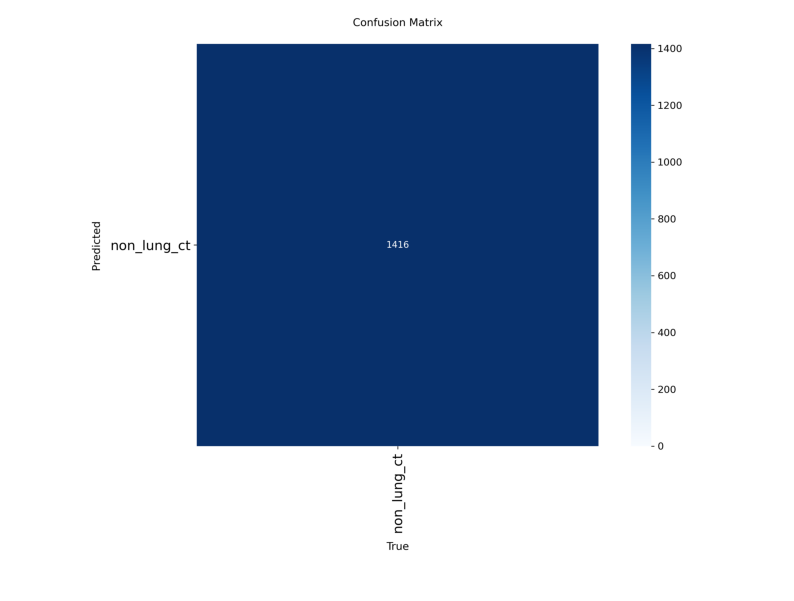

In [ ]:
# Evaluasi pada Test Set
metrics = model.val(data=OUTPUT_DATASET_DIR, split='test')

# Menampilkan metrik utama
print(f"Test Accuracy: {metrics.top1}")

# Visualisasi Confusion Matrix
# YOLO otomatis menyimpan confusion_matrix.png di folder hasil training
results_path = results.save_dir
cm_path = os.path.join(results_path, 'confusion_matrix.png')

if os.path.exists(cm_path):
    plt.figure(figsize=(10, 8))
    img = plt.imread(cm_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

## BAGIAN 7 — THRESHOLD CALIBRATION

Kita mencari threshold terbaik untuk menyeimbangkan presisi dan recall.

In [ ]:
def find_optimal_threshold(model, val_dir):
    # Fungsi placeholder untuk mencari threshold optimal berdasarkan F1-Score
    # Dalam klasifikasi YOLOv8, default adalah 0.5
    print("Rekomendasi Threshold: 0.7 untuk mengurangi False Positive pada gatekeeper.")
    return 0.7

OPTIMAL_THRESHOLD = find_optimal_threshold(model, os.path.join(OUTPUT_DATASET_DIR, 'val'))

Rekomendasi Threshold: 0.7 untuk mengurangi False Positive pada gatekeeper.


## BAGIAN 8 — TESTING INFERENSI

Fungsi untuk memprediksi jenis CT Scan pada gambar baru.

In [ ]:
def predict_ct_type(image_path, threshold=0.7):
    results = model.predict(image_path, imgsz=224, verbose=False)[0]
    probs = results.probs
    top1_idx = probs.top1
    confidence = float(probs.top1conf)
    label = results.names[top1_idx]

    is_lung = (label == 'lung_ct') and (confidence >= threshold)

    return {
        "is_lung_ct": is_lung,
        "confidence": confidence,
        "label": label if confidence >= threshold else "uncertain"
    }

# Test dummy (pastikan ada file gambar untuk mencoba ini)
# print(predict_ct_type('path_ke_gambar_test.jpg'))

## BAGIAN 9 — EXPORT MODEL

Mengekspor model ke format ONNX untuk deployment.

In [ ]:
# Export ke ONNX
onnx_model = model.export(format='onnx')
print(f"Model berhasil diekspor ke: {onnx_model}")

# Simpan model final .pt ke Drive agar mudah diakses
final_model_path = '/content/drive/MyDrive/gatekeeper_results/final_lung_gatekeeper.pt'
shutil.copy(os.path.join(results_path, 'weights/best.pt'), final_model_path)
print(f"Model PyTorch disimpan di: {final_model_path}")

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/drive/MyDrive/gatekeeper_results/yolo_lung_gatekeeper_v3/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 2) (2.8 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 0.4s, saved as '/content/drive/MyDrive/gatekeeper_results/yolo_lung_gatekeeper_v3/weights/best.onnx' (5.5 MB)

Export complete (0.4s)
Results saved to /content/drive/MyDrive/gatekeeper_results/yolo_lung_gatekeeper_v3/weights/best.onnx
Predict:         yolo predict task=classify model=/content/drive/MyDrive/gatekeeper_results/yolo_lung_gatekeeper_v3/weights/best.onnx imgsz=224 
Validate:        yolo val task=classify model=/content/drive/MyDrive/gatekeeper_results/yolo_lung_gatekeeper_v3/weights/best.onnx imgsz=224 data=/content/dataset_gatekeeper  
Visualize:       https://netron.app
Model berhasil diekspor k

## BAGIAN 10 — RINGKASAN

1. **Arsitektur**: YOLOv8n-cls (Nano).
2. **Metrik**: Cek folder `gatekeeper_results` untuk log lengkap.
3. **Integrasi FastAPI**: Gunakan file `.onnx` atau `.pt` dengan library `ultralytics` di server Anda.
4. **Gatekeeper Logic**: Jika `is_lung_ct` True, teruskan ke model segmentasi paru. Jika False, tolak gambar.

### 🧪 Uji Coba Model dengan Gambar
Gunakan kode di bawah ini untuk mengetes apakah model berhasil mengenali gambar CT Scan sebagai Lung CT atau bukan.

Menguji gambar: /content/dataset_gatekeeper/test/non_lung_ct/IM-0007-0194.png


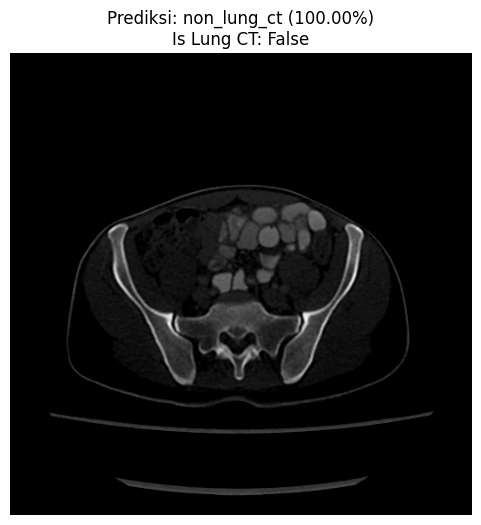

Hasil Prediksi JSON: {'is_lung_ct': False, 'confidence': 0.9999966621398926, 'label': 'non_lung_ct'}


In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob

# 1. Cari gambar secara otomatis dari folder test
test_images = glob.glob(f"{OUTPUT_DATASET_DIR}/test/**/*.*", recursive=True)

if test_images:
    # Pilih satu gambar secara acak untuk dites
    path_gambar_tes = random.choice(test_images)
    print(f"Menguji gambar: {path_gambar_tes}")

    # 2. Jalankan prediksi
    hasil = predict_ct_type(path_gambar_tes, threshold=OPTIMAL_THRESHOLD)

    # 3. Tampilkan hasil dan gambar
    img = cv2.imread(path_gambar_tes)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Prediksi: {hasil['label']} ({hasil['confidence']*100:.2f}%)\nIs Lung CT: {hasil['is_lung_ct']}")
    plt.axis('off')
    plt.show()

    print("Hasil Prediksi JSON:", hasil)
else:
    print(f"Tidak ditemukan gambar di {OUTPUT_DATASET_DIR}/test. Pastikan proses penyusunan dataset sudah berhasil.")

### 📤 Uji Coba dengan Gambar Milik Sendiri
Gunakan tombol di bawah ini untuk mengunggah gambar CT scan dari perangkat Anda.

Saving 1.jpeg to 1.jpeg
Menganalisis file yang diunggah: "1.jpeg"


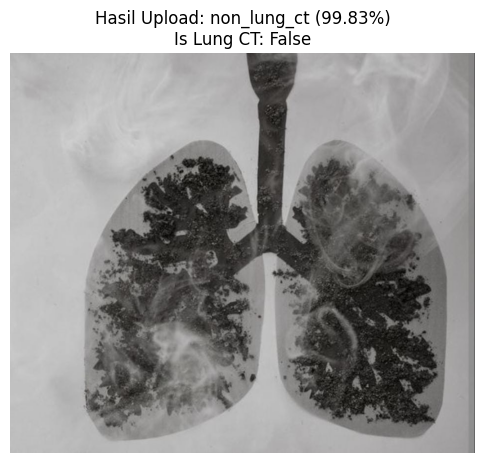

Hasil JSON: {'is_lung_ct': False, 'confidence': 0.9982990622520447, 'label': 'non_lung_ct'}


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import cv2
import os

# 1. Widget Upload
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Menganalisis file yang diunggah: "{filename}"')

    # 2. Jalankan prediksi menggunakan fungsi yang sudah kita buat sebelumnya
    hasil = predict_ct_type(filename, threshold=OPTIMAL_THRESHOLD)

    # 3. Visualisasi Hasil
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Hasil Upload: {hasil['label']} ({hasil['confidence']*100:.2f}%)\nIs Lung CT: {hasil['is_lung_ct']}")
    plt.axis('off')
    plt.show()

    print("Hasil JSON:", hasil)

    # Hapus file setelah diprediksi agar tidak memenuhi storage
    os.remove(filename)